In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler, PowerTransformer, OrdinalEncoder
from sklearn.model_selection import train_test_split

In [2]:
from google.colab import files
uploaded = files.upload()

Saving swiggy_cleaned.csv to swiggy_cleaned.csv


In [3]:

df = pd.read_csv('swiggy_cleaned.csv')

df

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,24,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,33,BANG,25,3,friday,0,5.0,19.0,evening,20.183530
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,26,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,21,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,windy,high,...,32,JAP,24,3,thursday,0,10.0,11.0,morning,1.489846
45498,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,NaN,2022-02-16,windy,jam,...,36,AGR,16,2,wednesday,0,15.0,19.0,evening,NaN
45499,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,cloudy,low,...,16,CHEN,11,3,friday,0,15.0,23.0,night,4.657195
45500,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,cloudy,high,...,26,COIMB,7,3,monday,0,5.0,13.0,afternoon,6.232393


In [4]:
df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance'],
      dtype='object')

In [5]:
columns_to_drop =  ['rider_id',
                    'restaurant_latitude',
                    'restaurant_longitude',
                    'delivery_latitude',
                    'delivery_longitude',
                    'order_date',
                    "order_time_hour",
                    "order_day"]

In [6]:
df.drop(columns=columns_to_drop, inplace=True)

In [7]:
df

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_of_day,distance
0,37.0,4.9,sunny,high,2,snack,motorcycle,0.0,no,urban,24,INDO,3,saturday,1,15.0,morning,3.025149
1,34.0,4.5,stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,BANG,3,friday,0,5.0,evening,20.183530
2,23.0,4.4,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,BANG,3,saturday,1,15.0,morning,1.552758
3,38.0,4.7,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,COIMB,4,tuesday,0,10.0,evening,7.790401
4,32.0,4.6,cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,CHEN,3,saturday,1,15.0,afternoon,6.210138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,30.0,4.8,windy,high,1,meal,motorcycle,0.0,no,metropolitian,32,JAP,3,thursday,0,10.0,morning,1.489846
45498,21.0,4.6,windy,jam,0,buffet,motorcycle,1.0,no,metropolitian,36,AGR,2,wednesday,0,15.0,evening,NaN
45499,30.0,4.9,cloudy,low,1,drinks,scooter,0.0,no,metropolitian,16,CHEN,3,friday,0,15.0,night,4.657195
45500,20.0,4.7,cloudy,high,0,snack,motorcycle,1.0,no,metropolitian,26,COIMB,3,monday,0,5.0,afternoon,6.232393


In [8]:
df.isna().sum()

,0
age,1854
ratings,1908
weather,525
traffic,510
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,993
festival,228
city_type,1198


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
missing_cols = (
                    df
                    .isna()
                    .any(axis=0)
                    .loc[lambda x: x]
                    .index
                )

missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'distance'],
      dtype='object')

# Data Prep

In [11]:
temp_df = df.copy()

In [12]:
temp_df = temp_df.assign(
                        distance_type = pd.cut(temp_df["distance"],bins=[0,5,10,15,25],
                                               right=False,labels=["short","medium","long","very_long"])
                                    )


In [13]:
temp_df = temp_df.dropna()

In [14]:
temp_df.isna().sum()

,0
age,0
ratings,0
weather,0
traffic,0
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,0
festival,0
city_type,0


In [15]:
X=temp_df.drop(columns='time_taken')
y=temp_df['time_taken']

In [16]:
X.shape

(38064, 18)

In [17]:
y.shape

(38064,)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [99]:
X_train

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,city_name,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
11029,26.0,4.7,windy,jam,2,snack,electric_scooter,1.0,no,metropolitian,MUM,3,wednesday,0,10.0,night,9.177684,medium
15665,21.0,4.9,windy,medium,2,drinks,motorcycle,1.0,no,metropolitian,SUR,3,thursday,0,5.0,afternoon,6.081536,medium
14475,NaN,NaN,stormy,low,2,meal,scooter,1.0,no,metropolitian,MYS,3,saturday,1,NaN,after_midnight,1.554563,short
29199,32.0,4.7,windy,medium,0,buffet,motorcycle,1.0,no,metropolitian,JAP,4,monday,0,15.0,evening,20.852271,very_long
22514,34.0,4.9,sandstorms,jam,1,meal,scooter,0.0,no,urban,RANCHI,3,wednesday,0,5.0,night,9.056096,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,29.0,4.7,sandstorms,jam,2,meal,scooter,0.0,no,metropolitian,COIMB,4,monday,0,5.0,evening,12.464367,long
44732,36.0,4.8,cloudy,low,0,buffet,motorcycle,0.0,no,urban,SUR,3,wednesday,0,10.0,morning,1.520432,short
38158,36.0,4.4,fog,jam,1,buffet,scooter,0.0,no,metropolitian,BHP,2,thursday,0,10.0,evening,NaN,NaN
860,25.0,4.9,windy,medium,2,meal,scooter,1.0,no,metropolitian,CHEN,3,saturday,1,5.0,evening,7.760938,medium


In [19]:
print("The size of train data is",X_train.shape)
print("The shape of test data is",X_test.shape)

The size of train data is (30451, 18)
The shape of test data is (7613, 18)


In [20]:
X_train.columns

Index(['age', 'ratings', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'city_name', 'order_month', 'order_day_of_week',
       'is_weekend', 'pickup_time_minutes', 'order_time_of_day', 'distance',
       'distance_type'],
      dtype='object')

In [21]:
X_train.dtypes

,0
age,float64
ratings,float64
weather,object
traffic,object
vehicle_condition,int64
type_of_order,object
type_of_vehicle,object
multiple_deliveries,float64
festival,object
city_type,object


In [22]:
temp_df

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,city_name,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,37.0,4.9,sunny,high,2,snack,motorcycle,0.0,no,urban,24,INDO,3,saturday,1,15.0,morning,3.025149,short
1,34.0,4.5,stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,BANG,3,friday,0,5.0,evening,20.183530,very_long
2,23.0,4.4,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,BANG,3,saturday,1,15.0,morning,1.552758,short
3,38.0,4.7,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,COIMB,4,tuesday,0,10.0,evening,7.790401,medium
4,32.0,4.6,cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,CHEN,3,saturday,1,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45496,35.0,4.2,windy,jam,2,drinks,motorcycle,1.0,no,metropolitian,33,RANCHI,3,tuesday,0,10.0,night,16.600272,very_long
45497,30.0,4.8,windy,high,1,meal,motorcycle,0.0,no,metropolitian,32,JAP,3,thursday,0,10.0,morning,1.489846,short
45499,30.0,4.9,cloudy,low,1,drinks,scooter,0.0,no,metropolitian,16,CHEN,3,friday,0,15.0,night,4.657195,short
45500,20.0,4.7,cloudy,high,0,snack,motorcycle,1.0,no,metropolitian,26,COIMB,3,monday,0,5.0,afternoon,6.232393,medium


In [29]:
temp_df[["age","ratings","distance","pickup_time_minutes"]]

,age,ratings,distance,pickup_time_minutes
0,37.0,4.9,3.025149,15.0
1,34.0,4.5,20.183530,5.0
2,23.0,4.4,1.552758,15.0
3,38.0,4.7,7.790401,10.0
4,32.0,4.6,6.210138,15.0
...,...,...,...,...
45496,35.0,4.2,16.600272,10.0
45497,30.0,4.8,1.489846,10.0
45499,30.0,4.9,4.657195,15.0
45500,20.0,4.7,6.232393,5.0


In [28]:
num_cols=["age","ratings","distance","pickup_time_minutes"]
nominal_cat_cols=["weather","type_of_order","type_of_vehicle","festival","city_type","city_name","order_month",
                    "order_day_of_week",
                    "is_weekend",
                    "order_time_of_day"]
ordinal_cat_cols=["traffic","distance_type"]

In [30]:
len(num_cols + nominal_cat_cols + ordinal_cat_cols)

16

In [31]:
for col in ordinal_cat_cols:
    print(col,temp_df[col].unique())

traffic ['high' 'jam' 'low' 'medium']
distance_type ['short', 'very_long', 'medium', 'long']
Categories (4, object): ['short' < 'medium' < 'long' < 'very_long']


In [32]:

traffic_order = ["low","medium","high","jam"]

distance_type_order = ["short","medium","long","very_long"]

In [33]:
preprocessor=ColumnTransformer(transformers=[
    ("scale",MinMaxScaler(),num_cols),
    ("OneHot",OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore"),nominal_cat_cols),
    ("Ordinal",OrdinalEncoder(categories=[traffic_order,distance_type_order]),ordinal_cat_cols)
])
preprocessor


ColumnTransformer(transformers=[('scale', MinMaxScaler(),
                                 ['age', 'ratings', 'distance',
                                  'pickup_time_minutes']),
                                ('OneHot',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['weather', 'type_of_order', 'type_of_vehicle',
                                  'festival', 'city_type', 'city_name',
                                  'order_month', 'order_day_of_week',
                                  'is_weekend', 'order_time_of_day']),
                                ('Ordinal',
                                 OrdinalEncoder(categories=[['low', 'medium',
                                                             'high', 'jam'],
                                                            ['short', 'medium',
                                                             'long',
                                                             'very_long']]),
                                 ['traffic', 'distance_type'])])

In [34]:
X_train_trans=preprocessor.fit_transform(X_train)
X_test_trans=preprocessor.transform(X_test)

In [35]:
X_train_trans

array([[0.05263158, 0.8       , 0.16362906, ..., 0.        , 3.        ,
        0.        ],
       [0.52631579, 0.96      , 0.15703647, ..., 1.        , 3.        ,
        0.        ],
       [0.63157895, 1.        , 0.16016016, ..., 1.        , 3.        ,
        0.        ],
       ...,
       [0.73684211, 0.92      , 0.15404398, ..., 1.        , 0.        ,
        0.        ],
       [0.36842105, 0.92      , 0.99290134, ..., 1.        , 0.        ,
        3.        ],
       [0.73684211, 0.64      , 0.47045928, ..., 1.        , 3.        ,
        2.        ]])

In [36]:
pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [37]:
pt.lambdas_

array([0.31530632])

In [38]:
y_train_pt

array([[-1.05872751],
       [ 0.05134387],
       [ 1.27171334],
       ...,
       [-0.91877473],
       [-0.91877473],
       [ 1.1037409 ]])

# Train Initial Baseline Model


In [39]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()
lr.fit(X_train_trans,y_train_pt)

LinearRegression()

In [40]:
y_pred_train = lr.predict(X_train_trans)
y_pred_test = lr.predict(X_test_trans)

In [41]:
y_pred_train

array([[-0.49964506],
       [-0.37908327],
       [ 0.61991214],
       ...,
       [-0.6248736 ],
       [-0.66360437],
       [ 1.28338701]])

In [42]:
y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [43]:
from sklearn.metrics import mean_absolute_error, r2_score

print(f"The train error is {mean_absolute_error(y_train,y_pred_train_org):.2f} minutes")
print(f"The test error is {mean_absolute_error(y_test,y_pred_test_org):.2f} minutes")

The train error is 4.96 minutes
The test error is 5.01 minutes


In [44]:
print(f"The train error is {r2_score(y_train,y_pred_train_org):.2f} minutes")
print(f"The test error is {r2_score(y_test,y_pred_test_org):.2f} minutes")

The train error is 0.55 minutes
The test error is 0.55 minutes


# Impute Missing values

In [45]:
temp_df = df.copy()

In [46]:
temp_df = temp_df.assign(
                        distance_type = pd.cut(temp_df["distance"],bins=[0,5,10,15,25],
                                               right=False,labels=["short","medium","long","very_long"])
                                    )


In [47]:
temp_df.columns

Index(['age', 'ratings', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_of_day', 'distance', 'distance_type'],
      dtype='object')

In [48]:
temp_df.isna().sum()

,0
age,1854
ratings,1908
weather,525
traffic,510
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,993
festival,228
city_type,1198


In [49]:
X = temp_df.drop(columns='time_taken')
y = temp_df['time_taken']

X

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,city_name,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,37.0,4.9,sunny,high,2,snack,motorcycle,0.0,no,urban,INDO,3,saturday,1,15.0,morning,3.025149,short
1,34.0,4.5,stormy,jam,2,snack,scooter,1.0,no,metropolitian,BANG,3,friday,0,5.0,evening,20.183530,very_long
2,23.0,4.4,sandstorms,low,0,drinks,motorcycle,1.0,no,urban,BANG,3,saturday,1,15.0,morning,1.552758,short
3,38.0,4.7,sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,COIMB,4,tuesday,0,10.0,evening,7.790401,medium
4,32.0,4.6,cloudy,high,1,snack,scooter,1.0,no,metropolitian,CHEN,3,saturday,1,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,30.0,4.8,windy,high,1,meal,motorcycle,0.0,no,metropolitian,JAP,3,thursday,0,10.0,morning,1.489846,short
45498,21.0,4.6,windy,jam,0,buffet,motorcycle,1.0,no,metropolitian,AGR,2,wednesday,0,15.0,evening,NaN,NaN
45499,30.0,4.9,cloudy,low,1,drinks,scooter,0.0,no,metropolitian,CHEN,3,friday,0,15.0,night,4.657195,short
45500,20.0,4.7,cloudy,high,0,snack,motorcycle,1.0,no,metropolitian,COIMB,3,monday,0,5.0,afternoon,6.232393,medium


In [50]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [51]:
pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [52]:
X_train.isna().sum()

,0
age,1470
ratings,1510
weather,421
traffic,407
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,795
festival,188
city_type,968


In [53]:
X_train["age"].describe()

,age
count,34931.000000
mean,29.569551
std,5.752869
min,20.000000
25%,25.000000
50%,30.000000
75%,35.000000
max,39.000000


In [54]:
X_train["age"].isna().sum()

np.int64(1470)

In [55]:
age_median=X_train["age"].median()
age_median

30.0

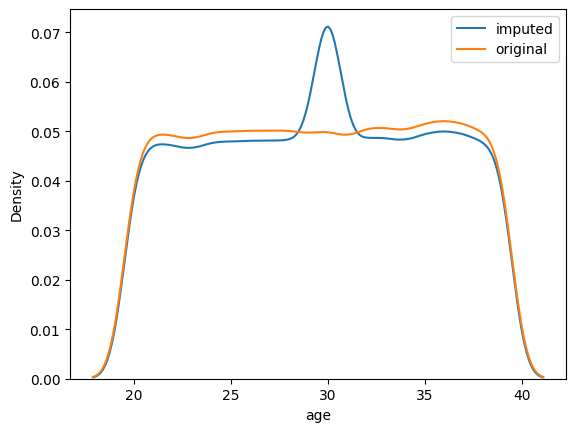

In [56]:
sns.kdeplot(X_train['age'].fillna(age_median),label="imputed")
sns.kdeplot(X_train['age'],label="original")

plt.legend()

In [57]:
temp_df.columns

Index(['age', 'ratings', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_of_day', 'distance', 'distance_type'],
      dtype='object')

In [58]:
X_train["ratings"].describe()

,ratings
count,34891.000000
mean,4.635058
std,0.314049
min,2.500000
25%,4.500000
50%,4.700000
75%,4.900000
max,5.000000


In [59]:
rating_mean=X_train["ratings"].mean()
rating_mean

np.float64(4.635057751282567)

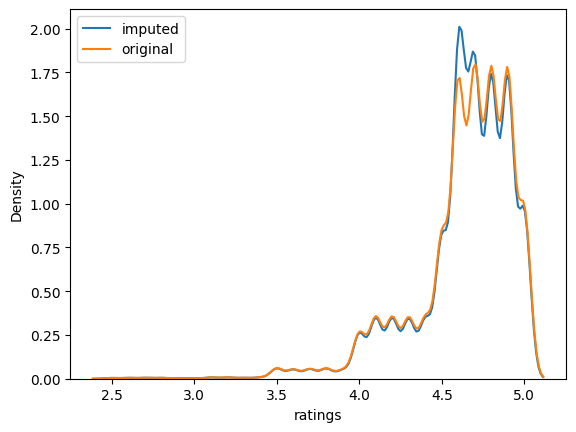

In [60]:
sns.kdeplot(X_train['ratings'].fillna(rating_mean),label="imputed")
sns.kdeplot(X_train['ratings'],label="original")

plt.legend()

## Weather

In [61]:
X_train['weather'].value_counts()

,count
weather,
fog,6160
stormy,6051
cloudy,6033
sandstorms,5958
windy,5928
sunny,5850


No dominant category to impute from

#Traffic

In [62]:
X_train["traffic"].value_counts()

,count
traffic,
low,12323
jam,11320
medium,8773
high,3578


## Multiple Deliveries

In [63]:

X_train['multiple_deliveries'].value_counts()

,count
multiple_deliveries,
1.0,22487
0.0,11252
2.0,1599
3.0,268


<Axes: xlabel='count', ylabel='multiple_deliveries'>

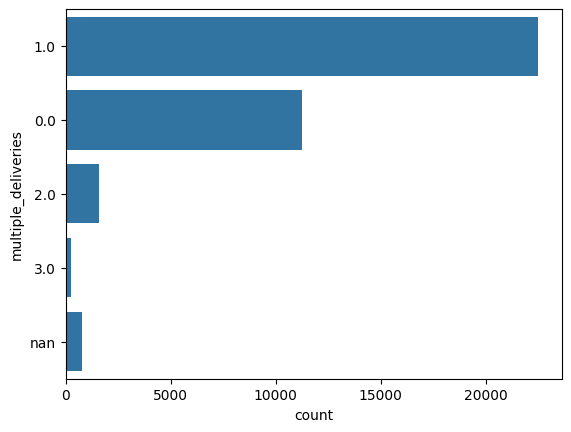

In [64]:
sns.countplot(X_train['multiple_deliveries'].apply(str))

In [65]:
# number of missing values

X_train['multiple_deliveries'].isna().sum()

np.int64(795)

In [66]:
# mode value

multiple_deliveries_mode = X_train['multiple_deliveries'].mode()[0]

In [67]:
multiple_deliveries_mode

np.float64(1.0)

<Axes: xlabel='count', ylabel='multiple_deliveries'>

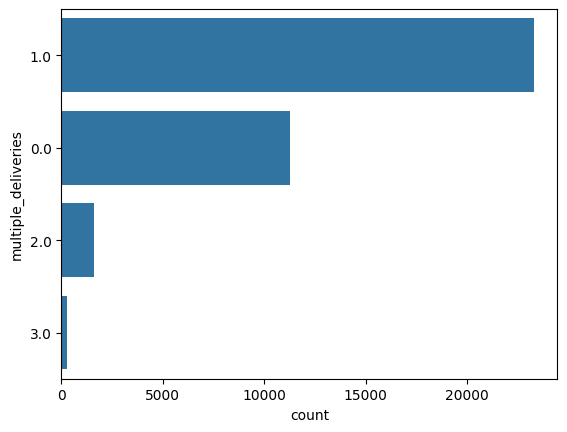

In [68]:
sns.countplot(X_train['multiple_deliveries'].fillna(multiple_deliveries_mode).apply(str))

:**Mode can be used for this column as an imputation technique**

## Festival

In [69]:
X_train['festival'].value_counts()

,count
festival,
no,35474
yes,739


<Axes: xlabel='count', ylabel='festival'>

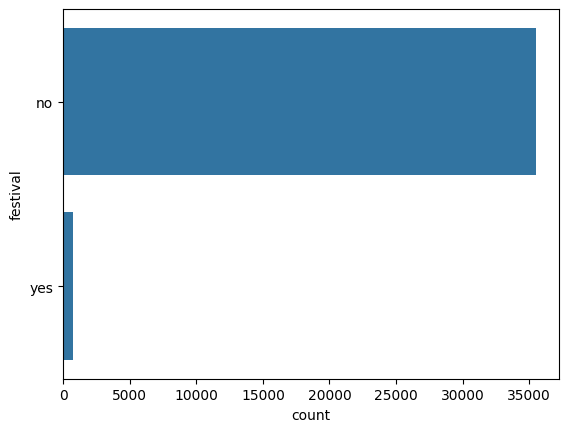

In [70]:
sns.countplot(X_train['festival'])

In [71]:
X_train['festival'].isna().sum()

np.int64(188)

In [72]:
festival_mode = X_train['festival'].mode()[0]

<Axes: xlabel='count', ylabel='festival'>

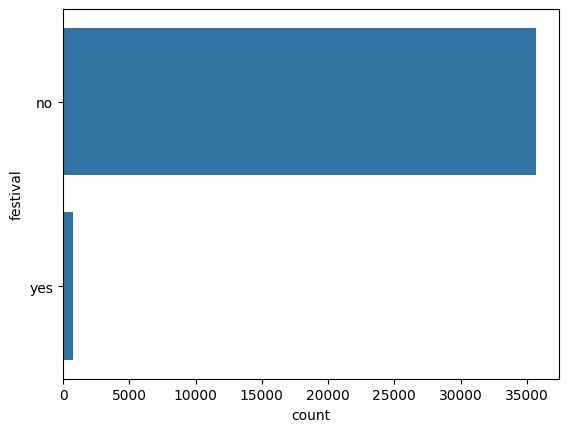

In [73]:
sns.countplot(X_train['festival'].fillna(festival_mode))

## City type

In [74]:
X_train['city_type'].value_counts()

,count
city_type,
metropolitian,27245
urban,8058
semi-urban,130


In [75]:

X_train['city_type'].isna().sum()

np.int64(968)

<Axes: xlabel='count', ylabel='city_type'>

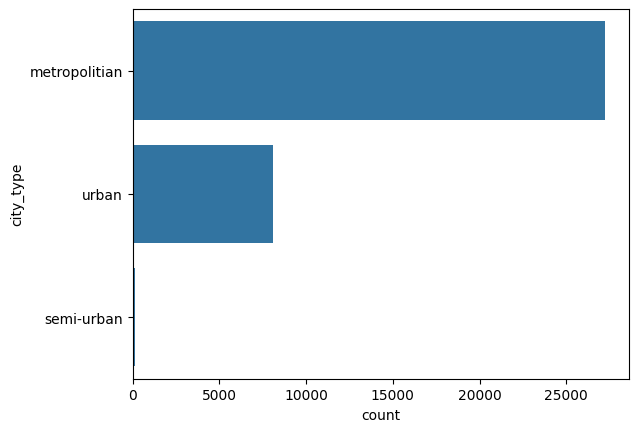

In [76]:
sns.countplot(X_train['city_type'])

In [80]:
# mode value

city_type_mode = X_train['city_type'].mode()[0]

<Axes: xlabel='count', ylabel='city_type'>

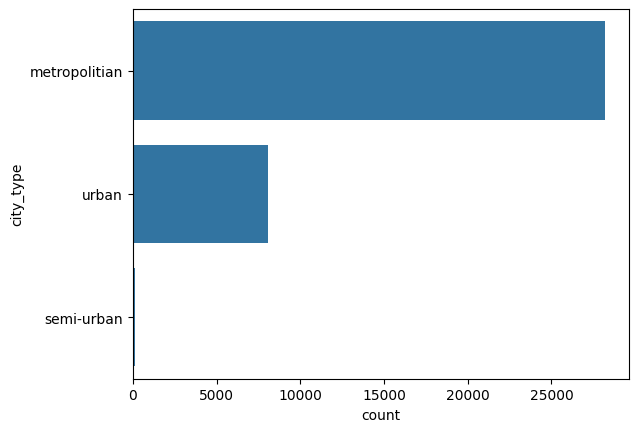

In [78]:
# fill with mode

sns.countplot(X_train['city_type'].fillna(city_type_mode))

In [79]:
missing_cols

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'distance'],
      dtype='object')

Pickup time minutes

In [81]:
X_train['pickup_time_minutes'].describe()

,pickup_time_minutes
count,35103.000000
mean,9.998718
std,4.082279
min,5.000000
25%,5.000000
50%,10.000000
75%,15.000000
max,15.000000


In [82]:
X_train['pickup_time_minutes'].isna().sum()

np.int64(1298)

In [83]:
pickup_time_minutes_median = X_train['pickup_time_minutes'].median()

In [84]:
pickup_time_minutes_median

10.0

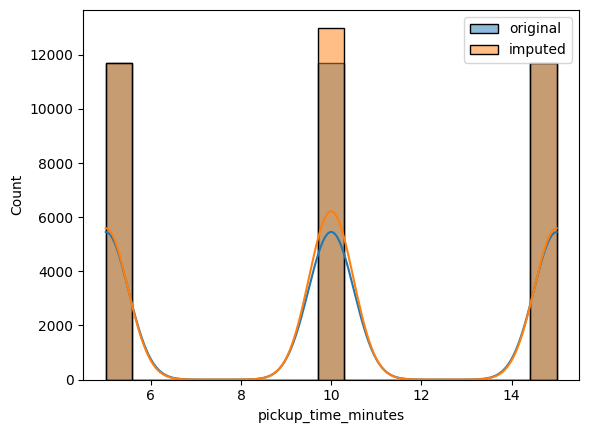

In [85]:
# histplot

sns.histplot(X_train['pickup_time_minutes'],kde=True,label='original')
sns.histplot(X_train['pickup_time_minutes'].fillna(pickup_time_minutes_median),kde=True,label='imputed')
plt.legend()

## Order time of day

In [86]:

X_train['order_time_of_day'].value_counts()

,count
order_time_of_day,
night,14620
evening,10732
morning,6150
afternoon,3253
after_midnight,1646


In [87]:
X_train['order_time_of_day'].isna().sum()

np.int64(0)

## Distance

In [88]:
X_train['distance'].isna().sum()

np.int64(2931)

In [89]:
distance_mean = X_train['distance'].mean()

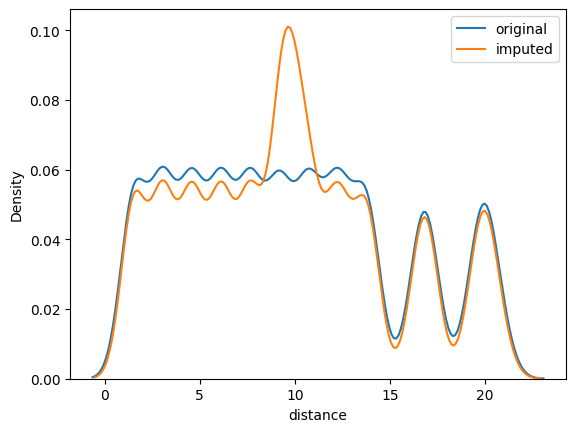

In [90]:

sns.kdeplot(X_train['distance'],label='original')
sns.kdeplot(X_train['distance'].fillna(distance_mean),label='imputed')
plt.legend()

# Imputation Pipeline

In [91]:
nominal_cat_cols

['weather',
 'type_of_order',
 'type_of_vehicle',
 'festival',
 'city_type',
 'city_name',
 'order_month',
 'order_day_of_week',
 'is_weekend',
 'order_time_of_day']

In [92]:
X_train.isna().sum()

,0
age,1470
ratings,1510
weather,421
traffic,407
vehicle_condition,0
type_of_order,0
type_of_vehicle,0
multiple_deliveries,795
festival,188
city_type,968


In [94]:
# features to fill values with mode
features_to_fill_mode = ['multiple_deliveries','festival','city_type']
features_to_fill_missing = [col for col in nominal_cat_cols if col not in features_to_fill_mode]
features_to_fill_missing

['weather',
 'type_of_order',
 'type_of_vehicle',
 'city_name',
 'order_month',
 'order_day_of_week',
 'is_weekend',
 'order_time_of_day']

In [95]:
# simple imputer to fill categorical vars with mode

simple_imputer = ColumnTransformer(transformers=[
    ("mode_imputer",SimpleImputer(strategy="most_frequent"),features_to_fill_mode),
    ("missing_imputer",SimpleImputer(strategy="constant",fill_value="missing"),features_to_fill_missing)
],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)

simple_imputer

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('mode_imputer',
                                 SimpleImputer(strategy='most_frequent'),
                                 ['multiple_deliveries', 'festival',
                                  'city_type']),
                                ('missing_imputer',
                                 SimpleImputer(fill_value='missing',
                                               strategy='constant'),
                                 ['weather', 'type_of_order', 'type_of_vehicle',
                                  'city_name', 'order_month',
                                  'order_day_of_week', 'is_weekend',
                                  'order_time_of_day'])],
                  verbose_feature_names_out=False)

In [96]:
simple_imputer.fit_transform(X_train)

array([[1.0, 'no', 'metropolitian', ..., 10.0, 9.177683834695673,
        'medium'],
       [1.0, 'no', 'metropolitian', ..., 5.0, 6.08153593718375, 'medium'],
       [1.0, 'no', 'metropolitian', ..., nan, 1.5545625412407005,
        'short'],
       ...,
       [0.0, 'no', 'metropolitian', ..., 10.0, nan, nan],
       [1.0, 'no', 'metropolitian', ..., 5.0, 7.760937776419092,
        'medium'],
       [0.0, 'no', 'metropolitian', ..., 15.0, 7.719540460983309,
        'medium']], dtype=object)

In [100]:
knn_imputer = KNNImputer(n_neighbors=5)

In [101]:
num_cols = ["age","ratings","pickup_time_minutes","distance"]

nominal_cat_cols = ['weather','type_of_order',
                    'type_of_vehicle',"festival",
                    "city_type","city_name","order_month",
                    "order_day_of_week",
                    "is_weekend",
                    "order_time_of_day"]

ordinal_cat_cols = ["traffic","distance_type"]

In [102]:

traffic_order = ["low","medium","high","jam"]

distance_type_order = ["short","medium","long","very_long"]

In [103]:
for col in ordinal_cat_cols:
    print(col,X_train[col].unique())

traffic ['jam' 'medium' 'low' 'high' nan]
distance_type ['medium', 'short', 'very_long', 'long', NaN]
Categories (4, object): ['short' < 'medium' < 'long' < 'very_long']


In [104]:
preprocessor = ColumnTransformer(transformers=[
    ("scale", MinMaxScaler(), num_cols),
    ("nominal_encode", OneHotEncoder(drop="first",handle_unknown="ignore",
                                     sparse_output=False), nominal_cat_cols),
    ("ordinal_encode", OrdinalEncoder(categories=[traffic_order,distance_type_order],
                                      encoded_missing_value=-999,
                                      handle_unknown="use_encoded_value",
                                      unknown_value=-1), ordinal_cat_cols)
],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)


preprocessor

ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                  remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['age', 'ratings', 'pickup_time_minutes',
                                  'distance']),
                                ('nominal_encode',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['weather', 'type_of_order', 'type_of_vehicle',
                                  'festival', 'city_type', 'city_name',
                                  'order_month', 'order_day_of_week',
                                  'is_weekend', 'order_time_of_day']),
                                ('ordinal_encode',
                                 OrdinalEncoder(categories=[['low', 'medium',
                                                             'high', 'jam'],
                                                            ['short', 'medium',
                                                             'long',
                                                             'very_long']],
                                                encoded_missing_value=-999,
                                                handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['traffic', 'distance_type'])],
                  verbose_feature_names_out=False)

In [105]:
preprocessor.fit_transform(X_train)

array([[ 0.31578947,  0.88      ,  0.5       , ...,  1.        ,
         2.        ,  1.        ],
       [ 0.05263158,  0.96      ,  0.        , ...,  1.        ,
         2.        ,  1.        ],
       [        nan,         nan,         nan, ...,  0.        ,
         2.        ,  1.        ],
       ...,
       [ 0.84210526,  0.76      ,  0.5       , ..., -1.        ,
         1.        ,  0.        ],
       [ 0.26315789,  0.96      ,  0.        , ...,  1.        ,
         2.        ,  1.        ],
       [ 0.47368421,  0.92      ,  1.        , ...,  1.        ,
         2.        ,  0.        ]])

In [106]:
# build the pipeline

processing_pipeline = Pipeline(steps=[
                                ("simple_imputer",simple_imputer),
                                ("preprocess",preprocessor),
                                ("knn_imputer",knn_imputer)
                            ])

processing_pipeline

Pipeline(steps=[('simple_imputer',
                 ColumnTransformer(force_int_remainder_cols=False, n_jobs=-1,
                                   remainder='passthrough',
                                   transformers=[('mode_imputer',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['multiple_deliveries',
                                                   'festival', 'city_type']),
                                                 ('missing_imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant'),
                                                  ['weather', 'type_of_order',
                                                   'type_of_vehi...
                                                   'city_name', 'order_month',
                                                   'order_day_of_week',
                                                   'is_weekend',
                                                   'order_time_of_day']),
                                                 ('ordinal_encode',
                                                  OrdinalEncoder(categories=[['low',
                                                                              'medium',
                                                                              'high',
                                                                              'jam'],
                                                                             ['short',
                                                                              'medium',
                                                                              'long',
                                                                              'very_long']],
                                                                 encoded_missing_value=-999,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['traffic',
                                                   'distance_type'])],
                                   verbose_feature_names_out=False)),
                ('knn_imputer', KNNImputer())])

In [107]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

model_pipe = Pipeline(steps=[
                                ("preprocessing",processing_pipeline),
                                ("model",lr)
                            ])

model_pipe

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('simple_imputer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('mode_imputer',
                                                                   SimpleImputer(strategy='most_frequent'),
                                                                   ['multiple_deliveries',
                                                                    'festival',
                                                                    'city_type']),
                                                                  ('missing_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant'),
                                                                   ['weath...
                                                                    'is_weekend',
                                                                    'order_time_of_day']),
                                                                  ('ordinal_encode',
                                                                   OrdinalEncoder(categories=[['low',
                                                                                               'medium',
                                                                                               'high',
                                                                                               'jam'],
                                                                                              ['short',
                                                                                               'medium',
                                                                                               'long',
                                                                                               'very_long']],
                                                                                  encoded_missing_value=-999,
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1),
                                                                   ['traffic',
                                                                    'distance_type'])],
                                                    verbose_feature_names_out=False)),
                                 ('knn_imputer', KNNImputer())])),
                ('model', LinearRegression())])

In [ ]:
model_pipe.fit(X_train,y_train_pt)

In [ ]:
y_pred_train = model_pipe.predict(X_train)
y_pred_test = model_pipe.predict(X_test)

In [ ]:
y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

print(f"The train error is {mean_absolute_error(y_train,y_pred_train_org):.2f} minutes")
print(f"The test error is {mean_absolute_error(y_test,y_pred_test_org):.2f} minutes")

In [ ]:
print(f"The train r2 score is {r2_score(y_train,y_pred_train_org):.2f}")
print(f"The test r2 score is {r2_score(y_test,y_pred_test_org):.2f}")

In [119]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42,n_jobs=-1)

model_pipe = Pipeline(steps=[
                                ("preprocessing",processing_pipeline),
                                ("model",rf)
                            ])

model_pipe

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('simple_imputer',
                                  ColumnTransformer(force_int_remainder_cols=False,
                                                    n_jobs=-1,
                                                    remainder='passthrough',
                                                    transformers=[('mode_imputer',
                                                                   SimpleImputer(strategy='most_frequent'),
                                                                   ['multiple_deliveries',
                                                                    'festival',
                                                                    'city_type']),
                                                                  ('missing_imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant'),
                                                                   ['weath...
                                                                  ('ordinal_encode',
                                                                   OrdinalEncoder(categories=[['low',
                                                                                               'medium',
                                                                                               'high',
                                                                                               'jam'],
                                                                                              ['short',
                                                                                               'medium',
                                                                                               'long',
                                                                                               'very_long']],
                                                                                  encoded_missing_value=-999,
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1),
                                                                   ['traffic',
                                                                    'distance_type'])],
                                                    verbose_feature_names_out=False)),
                                 ('knn_imputer', KNNImputer())])),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

In [ ]:
model_pipe.fit(X_train,y_train_pt.values.ravel())

In [ ]:
# get the predictions
y_pred_train = model_pipe.predict(X_train)
y_pred_test = model_pipe.predict(X_test)

In [ ]:
# get the actual predictions values

y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

print(f"The train error is {mean_absolute_error(y_train,y_pred_train_org):.2f} minutes")
print(f"The test error is {mean_absolute_error(y_test,y_pred_test_org):.2f} minutes")

In [ ]:
print(f"The train r2 score is {r2_score(y_train,y_pred_train_org):.2f}")
print(f"The test r2 score is {r2_score(y_test,y_pred_test_org):.2f}")